
## Data Science with Python Internship – Task 4
**Dataset Used:** Titanic (loaded directly from seaborn's built-in datasets)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Author:** [Your Name]  
**Date:** 2025

---
## 1. Overview
The Titanic dataset contains information about passengers aboard the RMS Titanic, which sank in 1912.  
We will explore survival patterns by gender, age, class, and fare using 5+ visualizations.  
Key questions we'll answer:
- Who was more likely to survive?
- How did age, gender, and class affect survival?
- What does the fare distribution look like across classes?

In [7]:
# Step 1: Import all required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Apply a clean seaborn style for all plots
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 2. Load Dataset

In [8]:
# Step 2: Load Titanic dataset directly from seaborn
# This avoids needing a local CSV file — works anywhere!
df = sns.load_dataset('titanic')

print('Dataset Shape:', df.shape)  # (rows, columns)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (891, 15)

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
# Check column names and missing values
print('Column Info:')
print(df.info())

print('\nMissing Values per Column:')
print(df.isnull().sum())

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Missing Values per Column:
survived         0
pclass        

---
## 3. Data Cleaning
We handle missing values before plotting to avoid errors or misleading charts.

In [10]:
# Step 3: Data Cleaning

# Fill missing 'age' values with the median age
# Median is better than mean here because age can have outliers
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing 'embarked' with the most common port (mode)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Fill missing 'embark_town' similarly
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Drop 'deck' column — too many missing values (over 75%) to be useful
df.drop(columns=['deck'], inplace=True, errors='ignore')

# Verify — confirm no major missing values remain
print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


---
## 4. Feature Engineering
We create 2 new helpful columns from existing data to improve our analysis.

In [11]:
# Step 4: Feature Engineering

# Feature 1: FamilySize = number of siblings/spouses + parents/children aboard
# This tells us if a passenger was alone or with family
df['FamilySize'] = df['sibsp'] + df['parch']

# Feature 2: AgeGroup — bin passengers into meaningful age categories
df['AgeGroup'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 30, 50, 80],
    labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
)

print('New features created: FamilySize, AgeGroup')
print('\nAgeGroup distribution:')
print(df['AgeGroup'].value_counts())

print('\nFamilySize sample statistics:')
print(df['FamilySize'].describe())

New features created: FamilySize, AgeGroup

AgeGroup distribution:
AgeGroup
YoungAdult    447
Adult         241
Teen           70
Child          69
Senior         64
Name: count, dtype: int64

FamilySize sample statistics:
count    891.000000
mean       0.904602
std        1.613459
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       10.000000
Name: FamilySize, dtype: float64


---
## 5. Visualizations
> **Each chart answers a specific question about the Titanic data.**

### 📊 Chart 1: Age Distribution (Histogram)

FileNotFoundError: [Errno 2] No such file or directory: 'images/chart1_age_distribution.png'

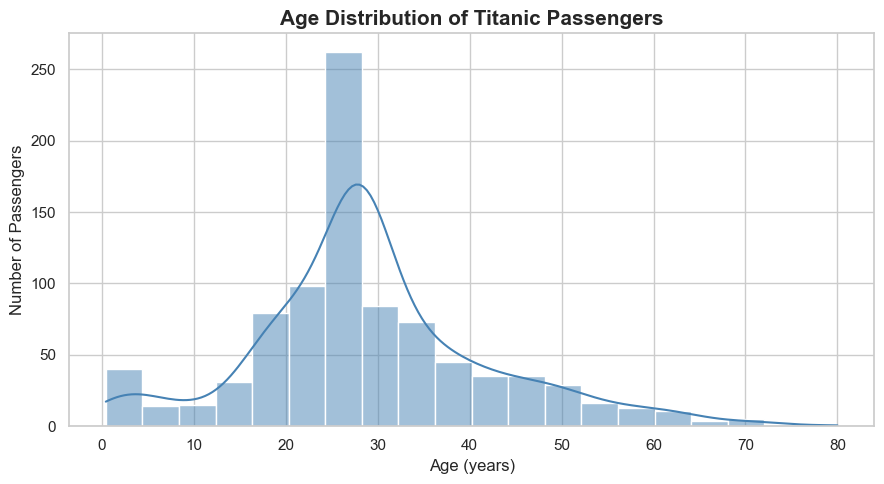

In [12]:
# Chart 1: Histogram — Age Distribution of all passengers
plt.figure(figsize=(9, 5))
sns.histplot(df['age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Titanic Passengers', fontsize=15, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.tight_layout()
plt.savefig('images/chart1_age_distribution.png', dpi=150)  # Save as PNG
plt.show()

**Insight:** Most Titanic passengers were between 20–35 years old, making Young Adults the largest group.  
The KDE curve shows a right skew — relatively fewer older passengers were aboard.

### 📊 Chart 2: Survival Rate by Gender (Bar Chart)

In [ ]:
# Chart 2: Bar Chart — Survival Rate by Gender
plt.figure(figsize=(7, 5))
sns.barplot(x='sex', y='survived', data=df, palette=['#E07B7B', '#7BAEE0'], errorbar=None)
plt.title('Survival Rate by Gender', fontsize=15, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Rate (0 = No, 1 = Yes)', fontsize=12)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('images/chart2_survival_by_gender.png', dpi=150)
plt.show()

**Insight:** Female passengers had a survival rate of ~74%, while males survived at only ~19%.  
This confirms the "women and children first" evacuation policy during the disaster.

### 📊 Chart 3: Fare Distribution by Passenger Class (Boxplot)

In [ ]:
# Chart 3: Boxplot — Fare by Passenger Class
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='pclass', y='fare', data=df,
    palette=['#FFD700', '#C0C0C0', '#CD7F32']  # Gold, Silver, Bronze
)
plt.title('Fare Distribution by Passenger Class', fontsize=15, fontweight='bold')
plt.xlabel('Passenger Class (1 = First, 2 = Second, 3 = Third)', fontsize=12)
plt.ylabel('Fare Paid (£)', fontsize=12)
plt.tight_layout()
plt.savefig('images/chart3_fare_by_class.png', dpi=150)
plt.show()

**Insight:** First class passengers paid significantly higher fares, with a wide spread and many high-paying outliers.  
Third class fares were tightly clustered at the low end, reflecting the economic gap between passengers.

### 📊 Chart 4: Age vs. Fare colored by Survival (Scatterplot)

In [ ]:
# Chart 4: Scatterplot — Age vs Fare, colored by Survival status
plt.figure(figsize=(9, 5))
sns.scatterplot(
    x='age', y='fare', hue='survived', data=df,
    palette={0: '#E07B7B', 1: '#7BAEE0'},
    alpha=0.6, edgecolor='white', linewidth=0.4
)
plt.title('Age vs. Fare (Colored by Survival)', fontsize=15, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Fare Paid (£)', fontsize=12)
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('images/chart4_age_vs_fare_survival.png', dpi=150)
plt.show()

**Insight:** Passengers who paid higher fares (especially above £100) had noticeably better survival rates.  
Age alone doesn't predict survival, but combined with fare (which links to class), a clear pattern emerges.

### 📊 Chart 5: Correlation Heatmap

In [ ]:
# Chart 5: Heatmap — Correlation between numeric columns
# Select only numeric columns for correlation
numeric_cols = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize']]

plt.figure(figsize=(9, 6))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,          # Show correlation numbers on the map
    fmt='.2f',           # Round to 2 decimal places
    cmap='coolwarm',     # Red = positive, Blue = negative correlation
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap — Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('images/chart5_correlation_heatmap.png', dpi=150)
plt.show()

**Insight:** `pclass` has a negative correlation with `survived` (−0.34) — lower class = lower survival chance.  
`fare` shows a positive correlation with survival (0.26), reinforcing that wealthier passengers fared better.

### 📊 Chart 6 (Bonus): Survival by Age Group and Gender (Facet Grid)

In [ ]:
# Chart 6 (Bonus): Survival Rate by Age Group, split by Gender
# This is a facet grid — a powerful way to compare subgroups
g = sns.catplot(
    data=df,
    x='AgeGroup', y='survived',
    col='sex',              # One chart per gender
    kind='bar',
    palette='muted',
    height=5, aspect=1.0,
    errorbar=None
)
g.set_axis_labels('Age Group', 'Survival Rate')
g.set_titles(col_template='Gender: {col_name}')
g.figure.suptitle('Survival Rate by Age Group and Gender', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
g.savefig('images/chart6_survival_agegroup_gender.png', dpi=150)
plt.show()

**Insight:** Female survival rates are consistently high across all age groups.  
Male children (Child group) had a relatively better survival chance than adult men, reflecting priority given to kids.

---
## 6. Insights Summary
Here's a quick summary of what we learned from the data:

| # | Finding |
|---|--------|
| 1 | Most passengers were **Young Adults (20–35 years)** |
| 2 | **Women survived at ~74%** vs. men at ~19% — gender was the strongest survival factor |
| 3 | **1st class passengers paid much more** and had far better survival odds |
| 4 | Passengers who paid **higher fares** were more likely to survive |
| 5 | **Passenger class (pclass)** has the strongest negative correlation with survival (−0.34) |
| 6 | Male children had better survival than adult men, showing age + gender both mattered |

---
## 7. Conclusion
This dashboard explored the Titanic dataset through 6 charts covering multiple dimensions: age, gender, class, and fare.

**Key Takeaways:**
- Survival was strongly influenced by **gender, class, and fare** — not age alone.
- Socioeconomic status (ticket class) had a major impact on who survived.
- Data cleaning and feature engineering (AgeGroup, FamilySize) helped reveal clearer patterns.

**What I practiced in this task:**
- Loading and cleaning a real-world dataset with pandas
- Engineering new features from raw columns
- Choosing the right chart type for the right question
- Telling a clear data story through visualization